# 5. Robustness tests of the Deep-LDA collective variable

This notebook extends `04_full.ipynb` (Section 1.1, cells "Define model" &rarr; "Extra: features relevance") with a systematic set of diagnostic tests on the Deep-LDA network:

1. **Repeated training** (`N_RUNS` independent fits with different random seeds) with per-run sensitivity analysis and a consensus feature ranking;
2. **Sweep of the number of network outputs** (width of the last hidden layer, before the LDA projection);
3. **Sweep of the activation function**;
4. **An independent re-implementation of the Deep-LDA objective in Keras/TensorFlow**, used to explore alternative architectures.

The Deep-LDA collective variable combines a feed-forward neural network with a linear-discriminant-analysis (LDA) projection trained to maximally separate the metastable states identified from short unbiased simulations (Bonati, Rizzi & Parrinello, *J. Phys. Chem. Lett.* **2020**, *11*, 2998–3004). The implementation used in `04_full.ipynb` relies on the `mlcolvar` library (Bonati, Trizio, Rizzi & Parrinello, *J. Chem. Phys.* **2023**, *159*, 014801), built on PyTorch/PyTorch-Lightning. The feature-relevance metric follows the sensitivity analysis defined in Bonati *et al.* (2020), Eq. 4, and the underlying discriminant criterion traces back to Fisher's linear discriminant (Fisher, R. A. *Ann. Eugen.* **1936**, *7*, 179–188).

> **Prerequisite.** This notebook assumes it is executed *after* cells 1–46 of `04_full.ipynb` in the same kernel (or with their outputs re-generated), so that `dataset`, `datamodule`, `colvar`, `X`, `y`, `n_states`, `accelerator`, and the baseline hyperparameters (`lrate`, `sw_reg`, `l2_reg`, `num_epochs`, `es_patience`, `es_min_delta`) are already defined. It has **not** been executed in this environment: the physical dataset (unbiased-MD `COLVAR` files) and the GROMACS/PLUMED/mlcolvar toolchain live on your local WSL2 installation and are not available here. Run it in your usual environment.


In [1]:
import os
import math
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import TQDMProgressBar

from mlcolvar.cvs import DeepLDA
from mlcolvar.data import DictModule
from mlcolvar.utils.io import create_dataset_from_files, load_dataframe
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
from mlcolvar.utils.fes import compute_fes
from mlcolvar.explain import sensitivity_analysis
import mlcolvar.utils.plot
import plumed


In [2]:
# Additional imports required for this notebook (on top of those in 04_full.ipynb cell [1])
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.cvs import DeepLDA
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.explain import sensitivity_analysis


In [20]:
# Configurations
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data2"
OUT_DIR     = BASE_DIR / "output"
GMX_CMD     = "gmx_mpi"  # I compiled gromacs with mpi support
#NUM_STEPS   = 10_000     # for testing  
NUM_STEPS   = 500_000    # productions 1ns
STRIDE      = 100

num_steps   = NUM_STEPS
sample_steps = 1_000_000
sample_stride = 100

os.chdir(BASE_DIR)
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [4]:
# helper functions

# delete outputs of simulations from `folder``
def clean(folder='./'):
    subprocess.run("rm -f bck.*.COLVAR bck.*.HILLS \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# delete outputs of simulations from `folder``
def clean_true(folder='./'):
    subprocess.run("rm -f bck.* COLVAR HILLS KERNELS alanine.* \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# execute bash command in the given folder
def execute(command, folder, background=False):
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output = True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

In [5]:
folderA = DATA_DIR / "0_unbiased-sA/"
folderB = DATA_DIR / "0_unbiased-sB/"

In [6]:
torch.set_float32_matmul_precision('high')

# Detect available accelerator
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
#accelerator = 'cpu'
print(f"Training on: {accelerator.upper()}")

Training on: GPU


In [7]:
filenames = [ f"{DATA_DIR}/0_unbiased-sA/COLVAR", 
              f"{DATA_DIR}/0_unbiased-sB/COLVAR" ]

n_states = len(filenames)

# load dataset
dataset, colvar = create_dataset_from_files(filenames,
                                        filter_args={'regex':'d_' }, # select distances between heavy atoms
                                        create_labels=True,
                                        return_dataframe=True, 
                                        )

# default parameters batch size = len(dataset), shuffle = True
datamodule = DictModule(dataset,lengths=[0.8,0.2])

Class 0 dataframe shape:  (5001, 53)
Class 1 dataframe shape:  (5001, 53)

 - Loaded dataframe (10002, 53): ['time', 'phi', 'psi', 'theta', 'xi', 'ene', 'd_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16', 'd_11_17', 'd_11_19', 'd_15_16', 'd_15_17', 'd_15_19', 'd_16_17', 'd_16_19', 'd_17_19', 'walker', 'labels']
 - Descriptors (10002, 45): ['d_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15

In [8]:
#------------- PARAMETERS -------------
n_input           = dataset['data'].shape[-1]
nodes             = [n_input,30,30,5]
activation        = 'tanh'  # changed from relu

lrate             = 0.001
sw_reg            = 0.05
l2_reg            = 1e-5

num_epochs        = 500
es_patience       = 50
es_min_delta      = 0.1

log_every         = 100
#--------------------------------------

nn_args = {'activation': activation}
options= {'nn': nn_args}

# MODEL
model = DeepLDA(nodes, n_states=n_states, options=options)

# OPTIMIZER: here we use adam
model.optimizer_name = "Adam"
model.optimizer_kwargs = {"lr": lrate, "weight_decay": l2_reg}

# REGULARIZATION: add regularization to the calculation of the S_w matrix
model.sw_reg = sw_reg

model

DeepLDA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=45, out_features=45, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=45, out_features=30, bias=True)
      (1): Tanh()
      (2): Linear(in_features=30, out_features=30, bias=True)
      (3): Tanh()
      (4): Linear(in_features=30, out_features=5, bias=True)
    )
  )
  (lda): LDA(in_features=5, out_features=1)
)

## 5.1 Common training routine

A thin wrapper around the training logic already used in cells 29–31 of `04_full.ipynb`, parametrised by architecture, activation function and random seed, so that it can be reused identically across all the tests below.


In [9]:
def train_deeplda(nodes, activation, seed,
                   max_epochs=num_epochs, lr=lrate, sw=sw_reg, l2=l2_reg,
                   patience=es_patience, min_delta=es_min_delta,
                   accelerator=accelerator, progress_bar=False):
    """
    Train a single Deep-LDA collective variable (Bonati, Rizzi & Parrinello,
    J. Phys. Chem. Lett. 2020, 11, 2998-3004) with a fixed random seed.

    Parameters
    ----------
    nodes : list[int]
        Layer sizes, e.g. [n_input, 30, 30, n_out].
    activation : str
        Activation function name accepted by mlcolvar's FeedForward block
        (e.g. 'relu', 'tanh', 'elu', 'sigmoid', 'softplus').
    seed : int
        Seed passed to lightning.seed_everything for reproducibility.

    Returns
    -------
    model : mlcolvar.cvs.DeepLDA
        The fitted model (in eval mode is left to the caller).
    metrics : mlcolvar.utils.trainer.MetricsCallback
        Callback holding the training/validation loss history.
    """
    lightning.seed_everything(seed, workers=True)

    options = {'nn': {'activation': activation}}
    model = DeepLDA(nodes, n_states=n_states, options=options)
    model.optimizer_name = "Adam"
    model.optimizer_kwargs = {"lr": lr, "weight_decay": l2}
    model.sw_reg = sw

    metrics = MetricsCallback()
    early_stopping = EarlyStopping(monitor="valid_loss", min_delta=min_delta,
                                    patience=patience, mode="min")

    trainer = lightning.Trainer(callbacks=[metrics, early_stopping],
                                 max_epochs=max_epochs, logger=None,
                                 enable_checkpointing=False, accelerator=accelerator,
                                 enable_progress_bar=progress_bar, enable_model_summary=False)

    trainer.fit(model, datamodule)
    model.eval()
    return model, metrics


## 5.2 Test 1 — Repeated training and consensus feature ranking

The network is trained `N_RUNS = 5` times from independent random initialisations (baseline architecture and activation, as in cell 29 of `04_full.ipynb`). For each run we compute the sensitivity analysis of Bonati *et al.* (2020, Eq. 4) and plot (i) the ranking of all descriptors and (ii) the distributions of the four most relevant ones, mirroring cells 43–45.


In [22]:
N_RUNS = 5
BASE_NODES = [dataset['data'].shape[-1], 30, 30, 5]
BASE_ACTIVATION = 'tanh'
plot_n_features = 4
seed = 1000

runs = []
for i in range(N_RUNS):
    seed =+ i
    print(f"=== Run {i+1}/{N_RUNS} (seed={seed}) ===")
    model_i, metrics_i = train_deeplda(BASE_NODES, BASE_ACTIVATION, seed)
    res_i = sensitivity_analysis(model_i, dataset, feature_names=dataset.feature_names,
                                  per_class=False, plot_mode=None)
    runs.append({'seed': seed, 'model': model_i, 'metrics': metrics_i, 'sensitivity': res_i})


Seed set to 0
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


=== Run 1/5 (seed=0) ===


/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


KEY:  data


KEY:  labels


=== Run 2/5 (seed=1) ===


Seed set to 2
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


KEY:  data


KEY:  labels


=== Run 3/5 (seed=2) ===


Seed set to 3
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


KEY:  data


KEY:  labels


=== Run 4/5 (seed=3) ===


Seed set to 4
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


KEY:  data


KEY:  labels


=== Run 5/5 (seed=4) ===
KEY:  data


KEY:  labels




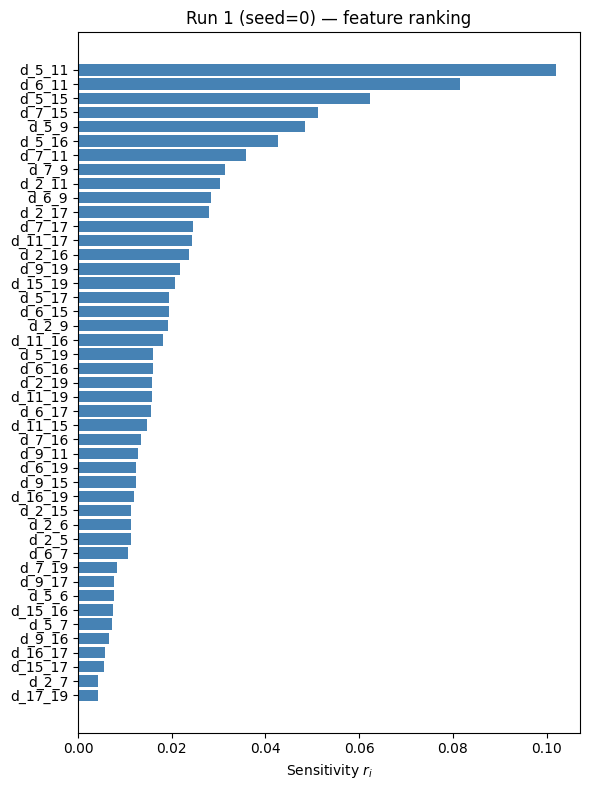

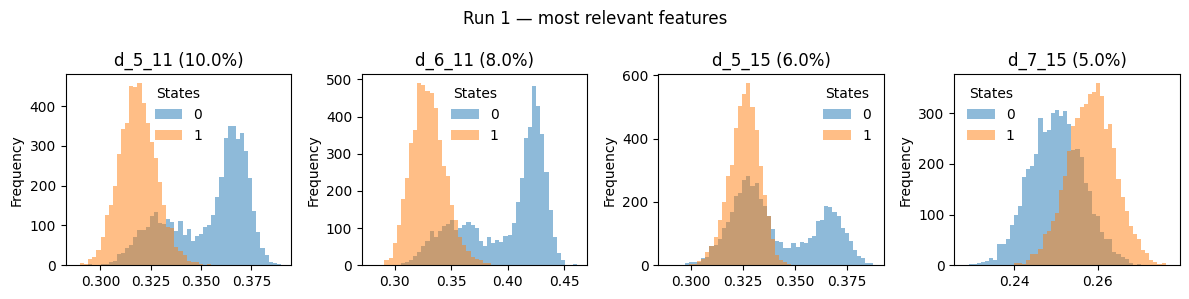

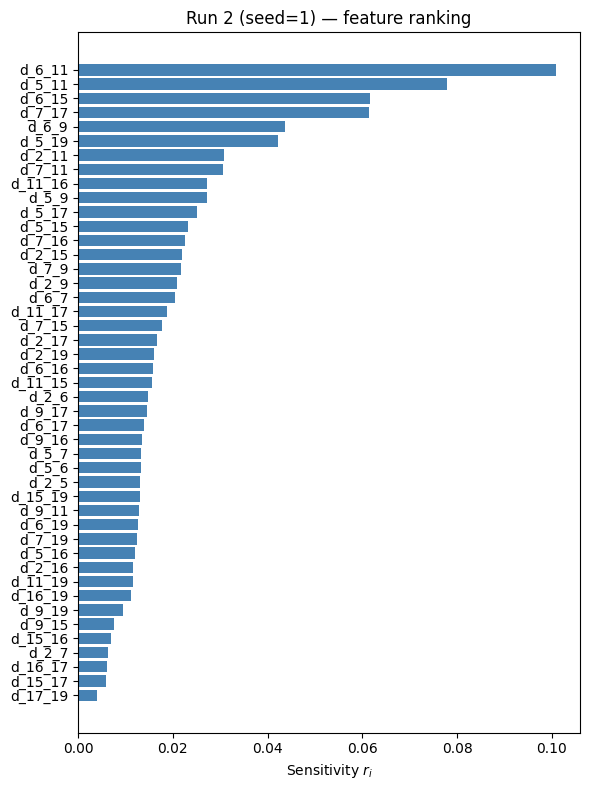

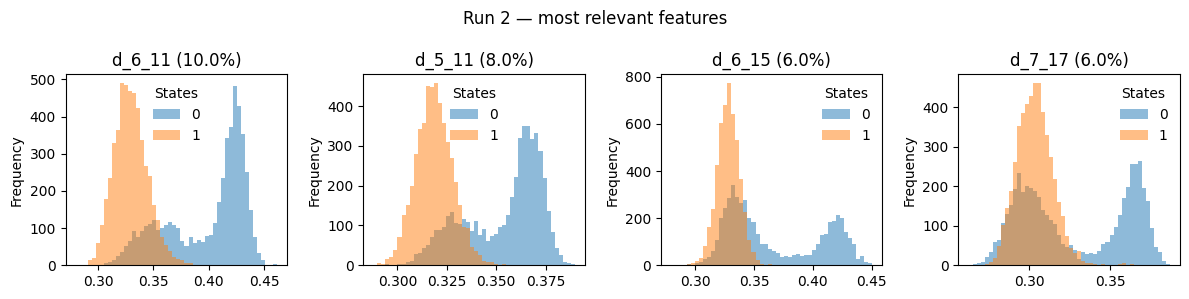

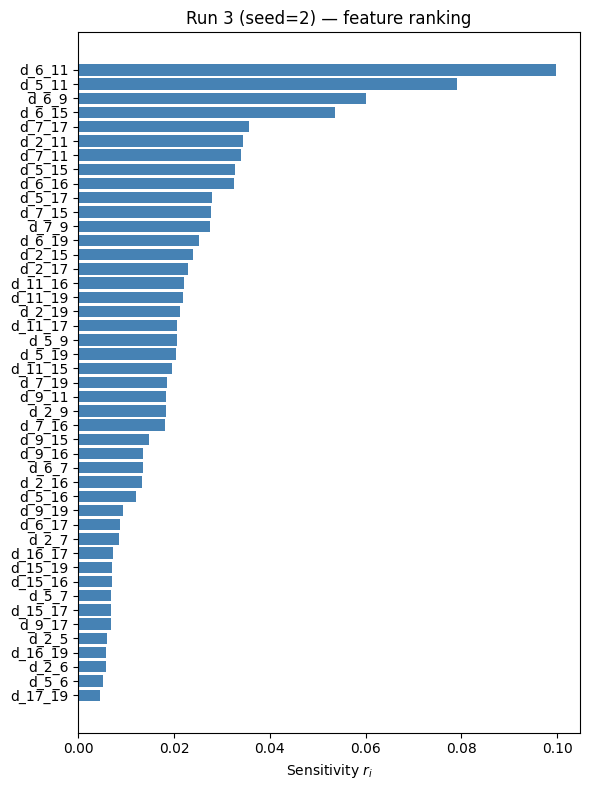

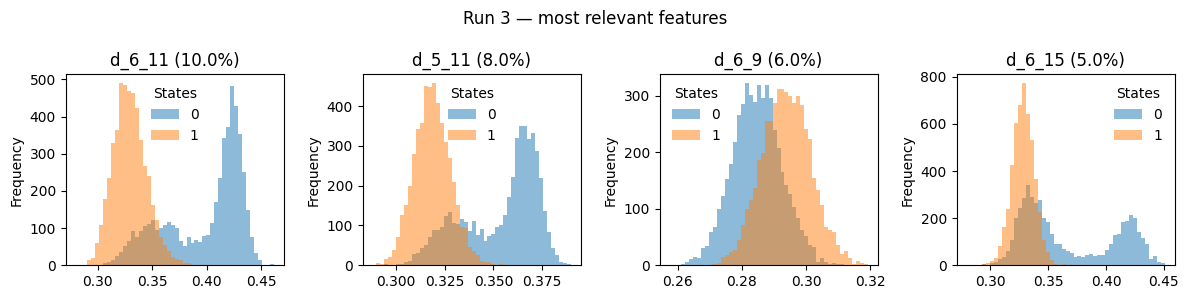

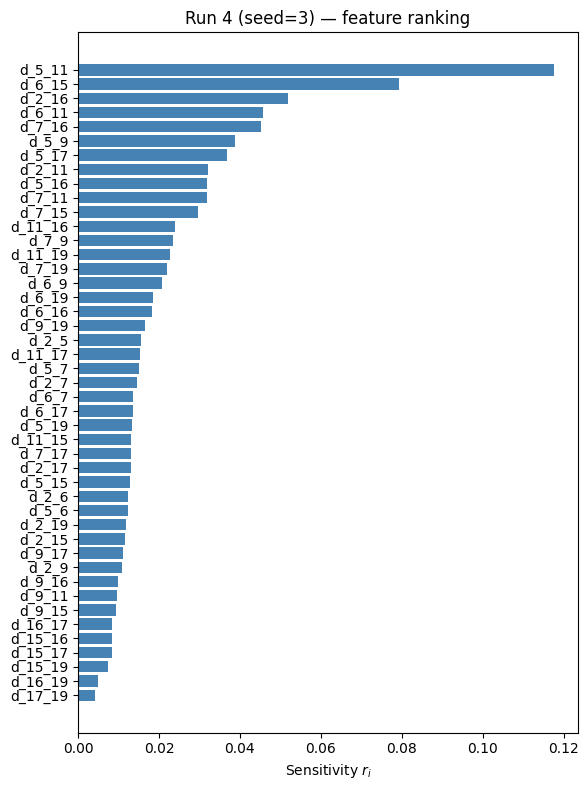

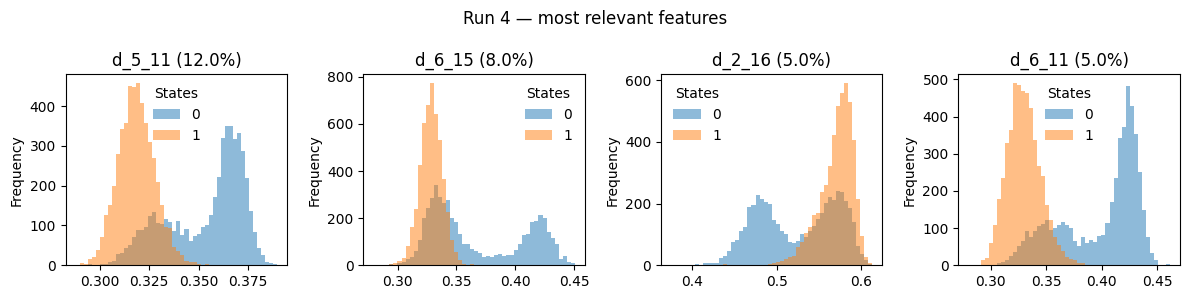

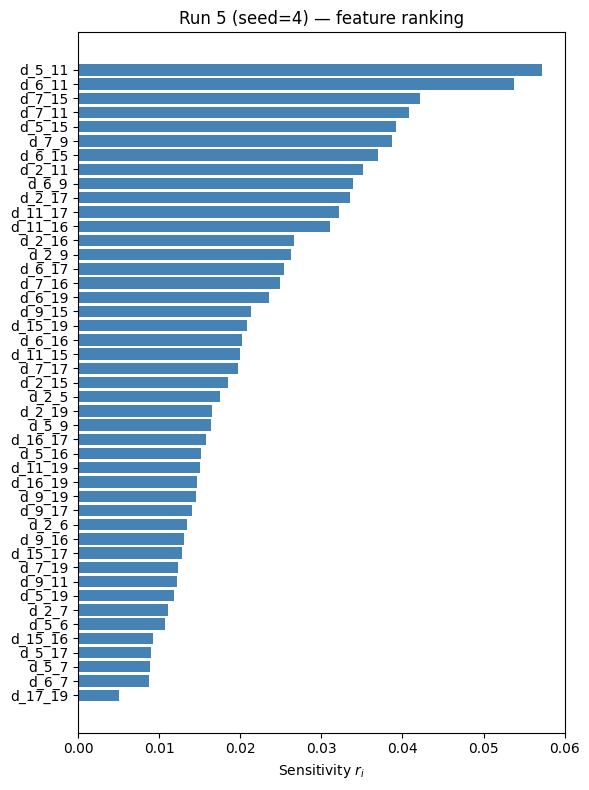

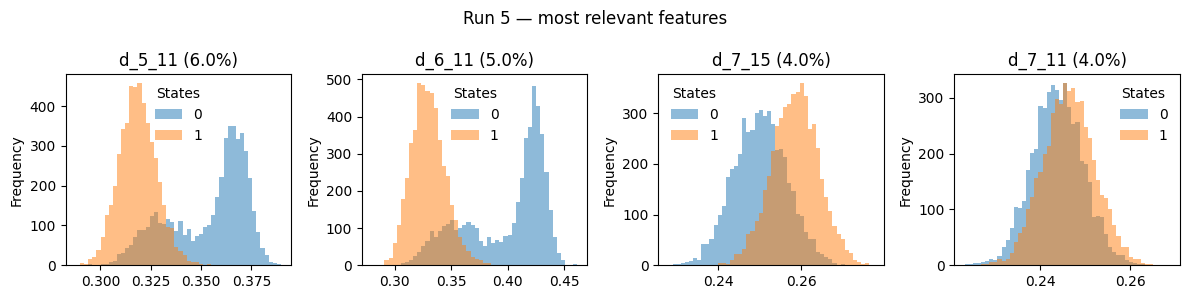

In [23]:
# Per-run diagnostics: full ranking (barh) + distributions of the top-4 features
for i, run in enumerate(runs):
    names = np.array(run['sensitivity']['feature_names'])
    sens = np.array(run['sensitivity']['sensitivity']['Dataset'])
    order = np.argsort(sens)
    names_sorted, sens_sorted = names[order], sens[order]

    fig, ax = plt.subplots(figsize=(6, 8), dpi=100)
    ax.barh(names_sorted, sens_sorted, color='steelblue')
    ax.set_xlabel(r'Sensitivity $r_i$')
    ax.set_title(f'Run {i+1} (seed={run["seed"]}) — feature ranking')
    plt.tight_layout()
    plt.show()

    top_names = names_sorted[-plot_n_features:]
    top_sens = sens_sorted[-plot_n_features:]
    fig, axs = plt.subplots(1, plot_n_features, figsize=(3 * plot_n_features, 3), dpi=100)
    plt.suptitle(f'Run {i+1} — most relevant features')
    for ax, name, s in zip(axs.flatten()[::-1], top_names, top_sens):
        colvar.pivot(columns='labels')[name].plot.hist(bins=50, alpha=0.5, ax=ax)
        ax.set_title(f'{name} ({np.round(s * 100)}%)')
        ax.legend(title='States', frameon=False)
    plt.tight_layout()
    plt.show()


Grafico salvato con successo in: /home/dani/wslcoding/MCFM/ML-CV/output/Run_1__seed_0__Comprehensive_Diagnostics.png


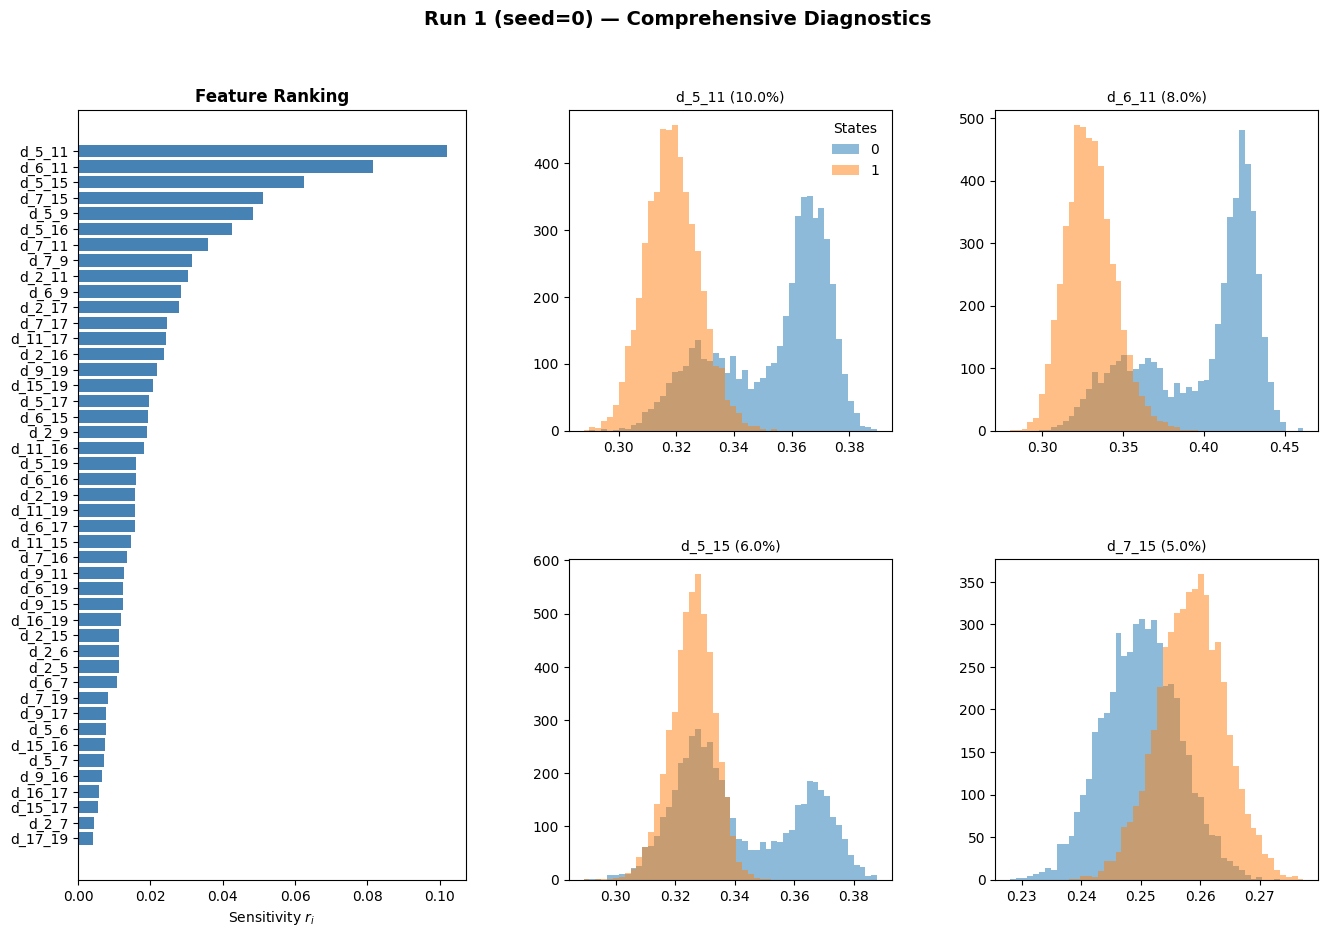

Grafico salvato con successo in: /home/dani/wslcoding/MCFM/ML-CV/output/Run_2__seed_1__Comprehensive_Diagnostics.png


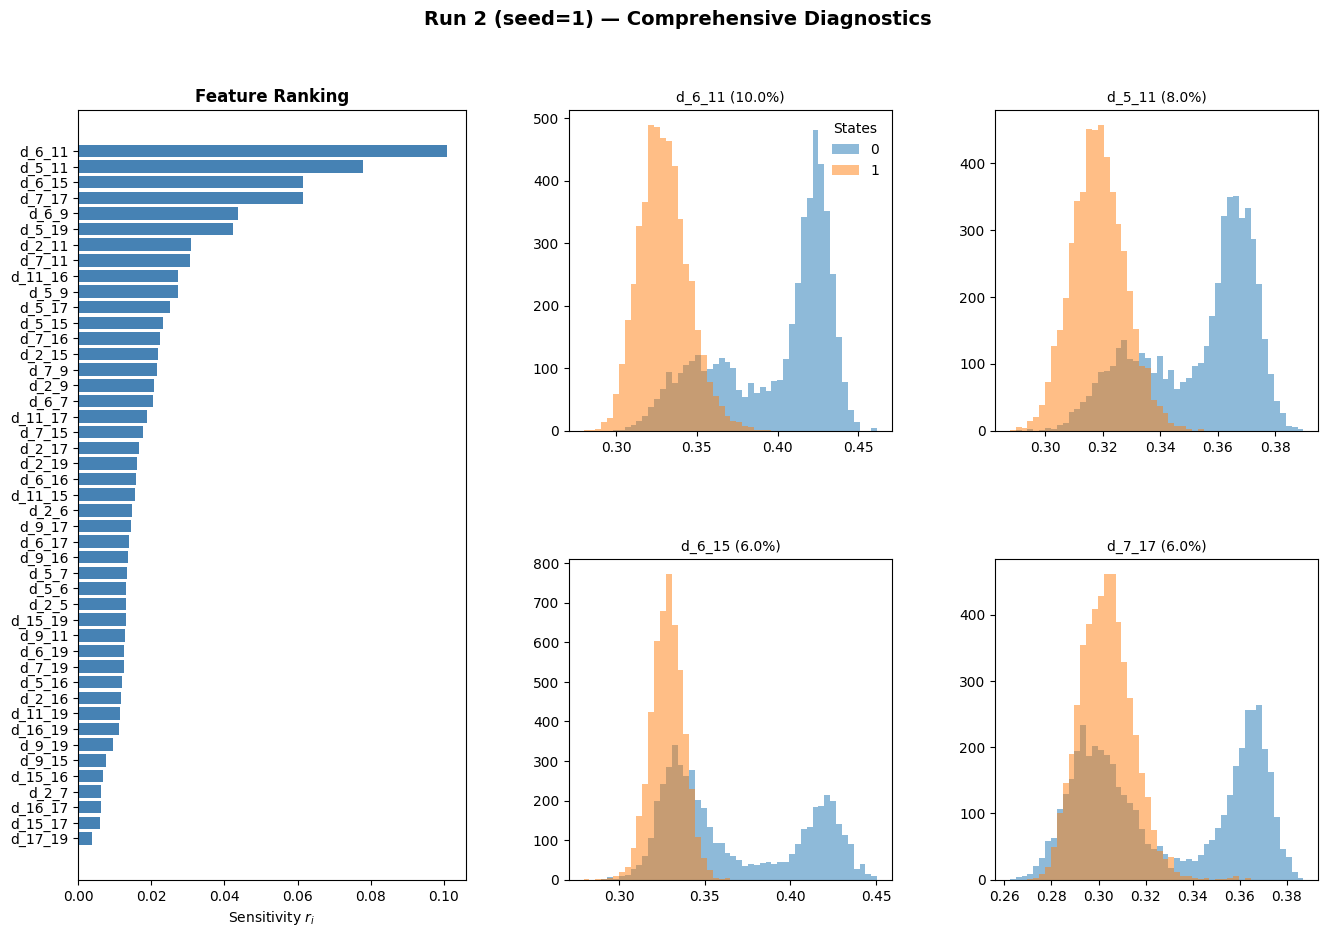

Grafico salvato con successo in: /home/dani/wslcoding/MCFM/ML-CV/output/Run_3__seed_2__Comprehensive_Diagnostics.png


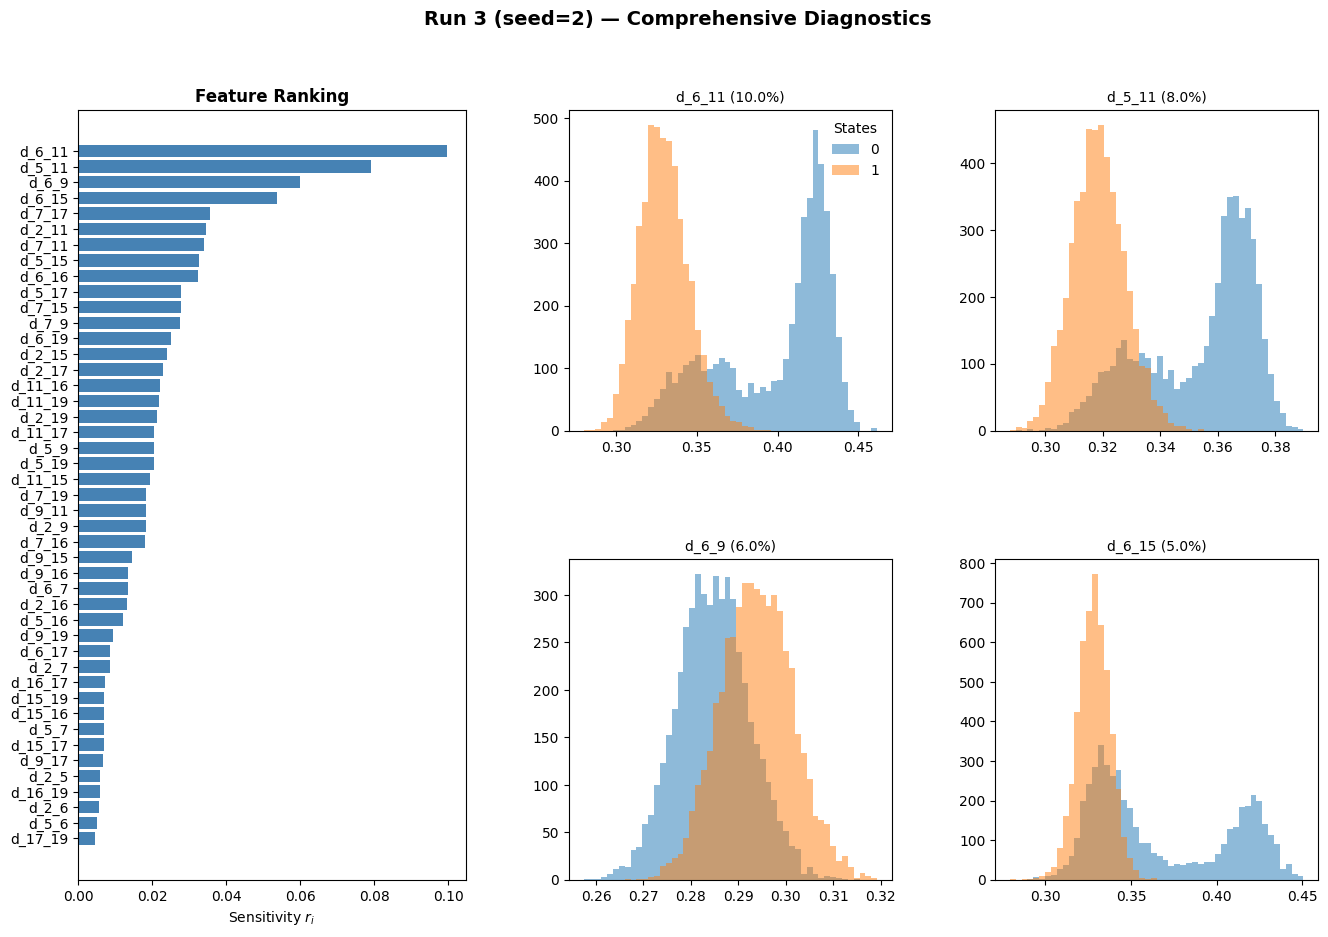

Grafico salvato con successo in: /home/dani/wslcoding/MCFM/ML-CV/output/Run_4__seed_3__Comprehensive_Diagnostics.png


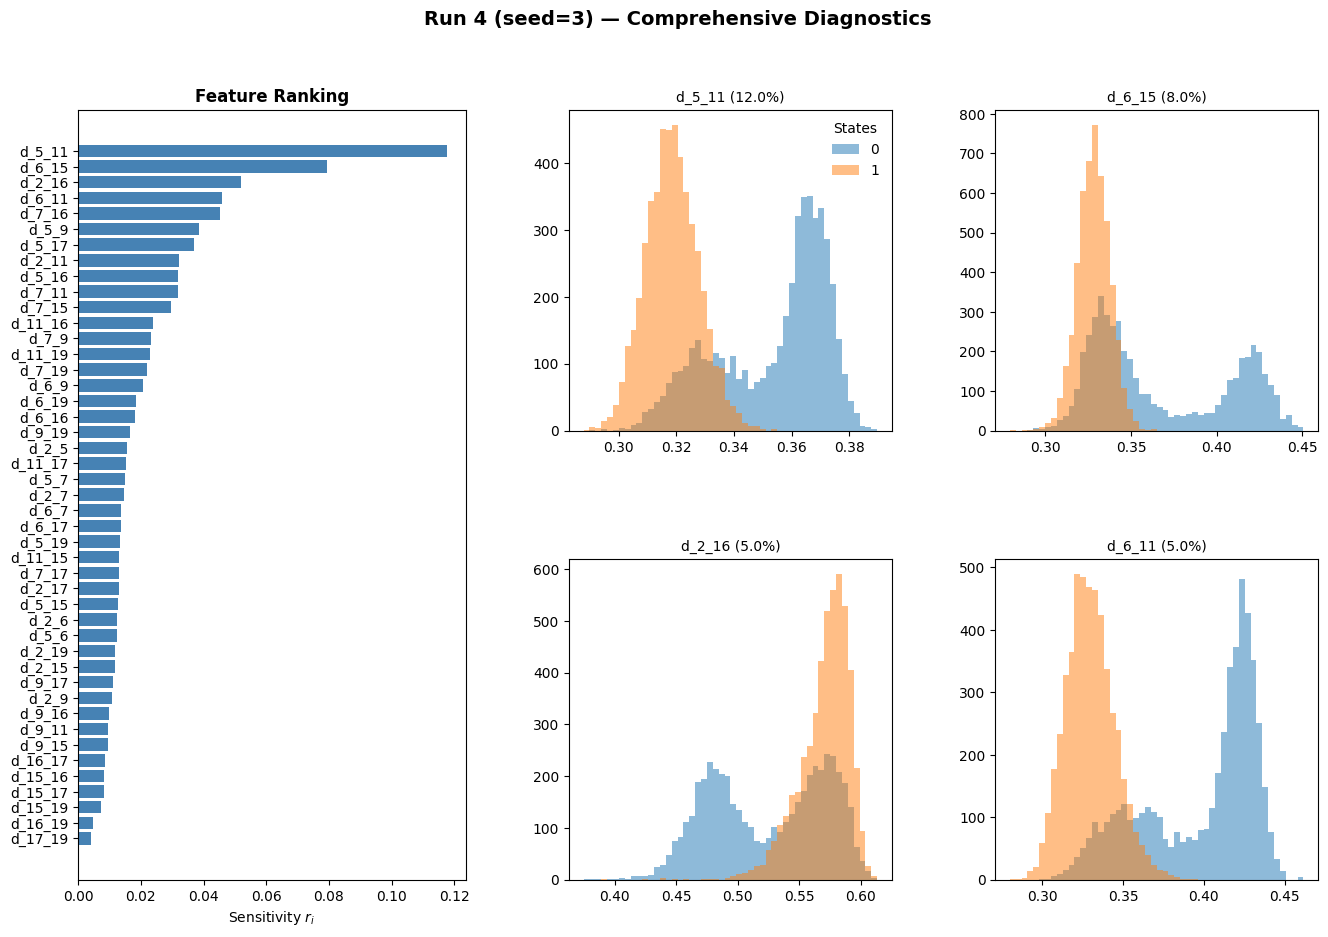

Grafico salvato con successo in: /home/dani/wslcoding/MCFM/ML-CV/output/Run_5__seed_4__Comprehensive_Diagnostics.png


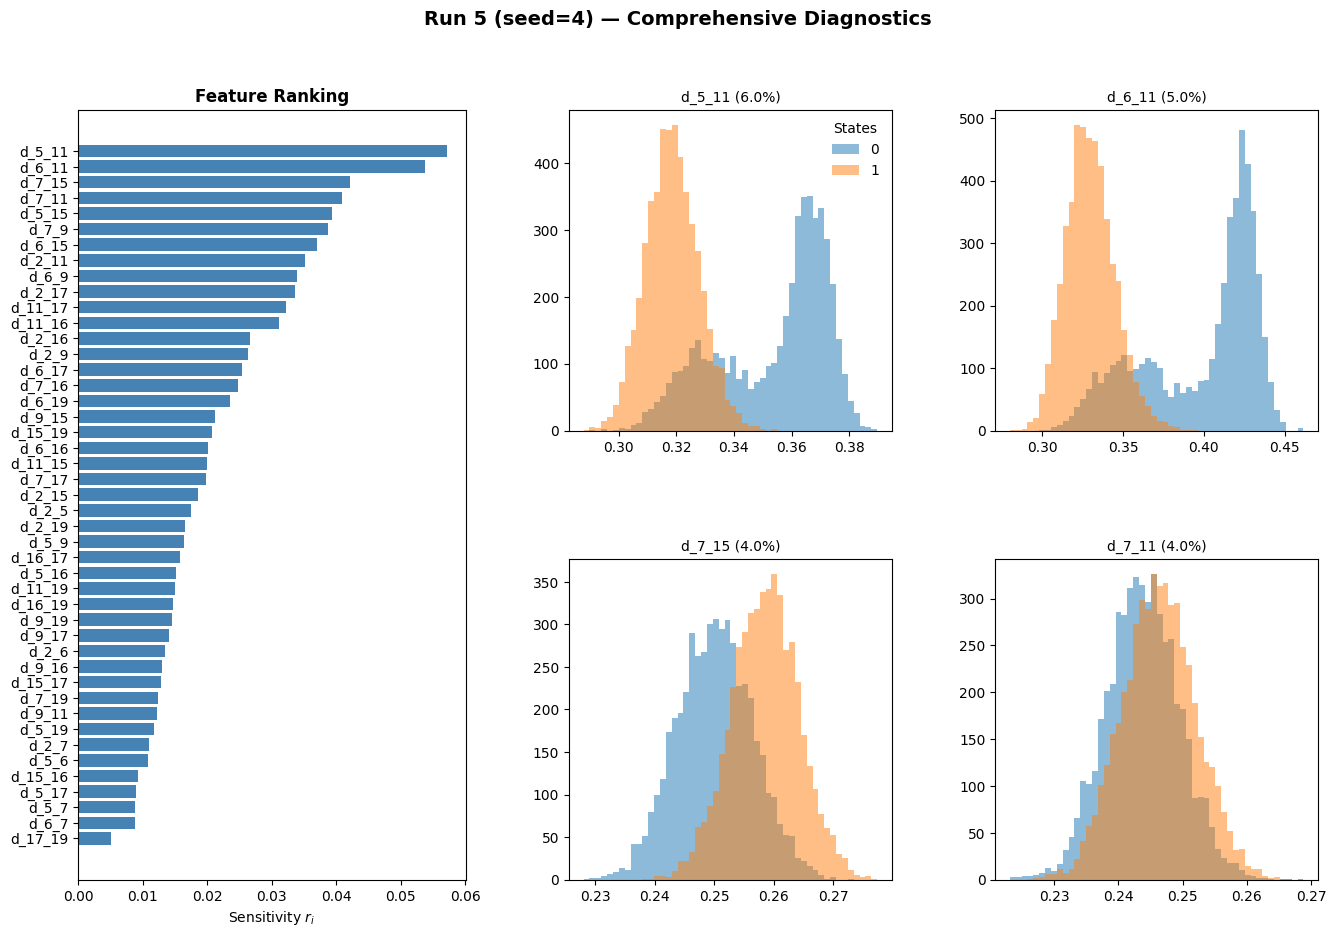

In [24]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import re

# Configurazione del numero di feature da mostrare
plot_n_features = 4

for i, run in enumerate(runs):
    names = np.array(run["sensitivity"]["feature_names"])
    sens = np.array(run["sensitivity"]["sensitivity"]["Dataset"])
    order = np.argsort(sens)
    names_sorted, sens_sorted = names[order], sens[order]

    # --- CREAZIONE DEL PLOT UNICO ---
    fig = plt.figure(figsize=(16, 10), dpi=100)

    # Definiamo il titolo principale
    title_text = f'Run {i+1} (seed={run["seed"]}) — Comprehensive Diagnostics'
    fig.suptitle(title_text, fontsize=14, weight="bold")

    # Griglia: 2 righe x 3 colonne (Colonna 0 intera per il barh, colonne 1 e 2 per gli istogrammi)
    gs = gridspec.GridSpec(
        2, 3, figure=fig, width_ratios=[1.2, 1, 1], wspace=0.3, hspace=0.4
    )

    # 1. Grafico a barre (prende tutta la prima colonna)
    ax_bar = fig.add_subplot(gs[:, 0])
    ax_bar.barh(names_sorted, sens_sorted, color="steelblue")
    ax_bar.set_xlabel(r"Sensitivity $r_i$")
    ax_bar.set_title("Feature Ranking", weight="bold")

    # 2. Distribuzioni delle top-4 feature
    top_names = names_sorted[-plot_n_features:]
    top_sens = sens_sorted[-plot_n_features:]

    top_names_rev = top_names[::-1]
    top_sens_rev = top_sens[::-1]

    hist_positions = [(0, 1), (0, 2), (1, 1), (1, 2)]

    for idx, (name, s) in enumerate(zip(top_names_rev, top_sens_rev)):
        if idx >= len(hist_positions):
            break

        r, c = hist_positions[idx]
        ax_hist = fig.add_subplot(gs[r, c])

        colvar.pivot(columns="labels")[name].plot.hist(
            bins=50, alpha=0.5, ax=ax_hist
        )
        ax_hist.set_title(f"{name} ({np.round(s * 100)}%)", fontsize=10)

        if idx == 0:
            ax_hist.legend(title="States", frameon=False, loc="upper right")
        else:
            ax_hist.get_legend().remove()

        ax_hist.set_ylabel("")

    # Ottimizzazione spazi prima del salvataggio
    plt.subplots_adjust(top=0.88)

    # --- SALVATAGGIO AUTOMATICO ---
    # Rendiamo il titolo un nome file valido (rimuovendo spazi extra e caratteri speciali)
    filename_clean = re.sub(r"[^\w\-_.]", "_", title_text.replace(" — ", "_"))
    filepath = OUT_DIR / f"{filename_clean}.png"

    # Salva il grafico in formato PNG (bbox_inches='tight' evita il taglio dei testi)
    fig.savefig(filepath, bbox_inches="tight", dpi=100)
    print(f"Grafico salvato con successo in: {filepath}")

    # Mostra a schermo
    plt.show()
    plt.close(fig)  # Chiude la figura per liberare memoria

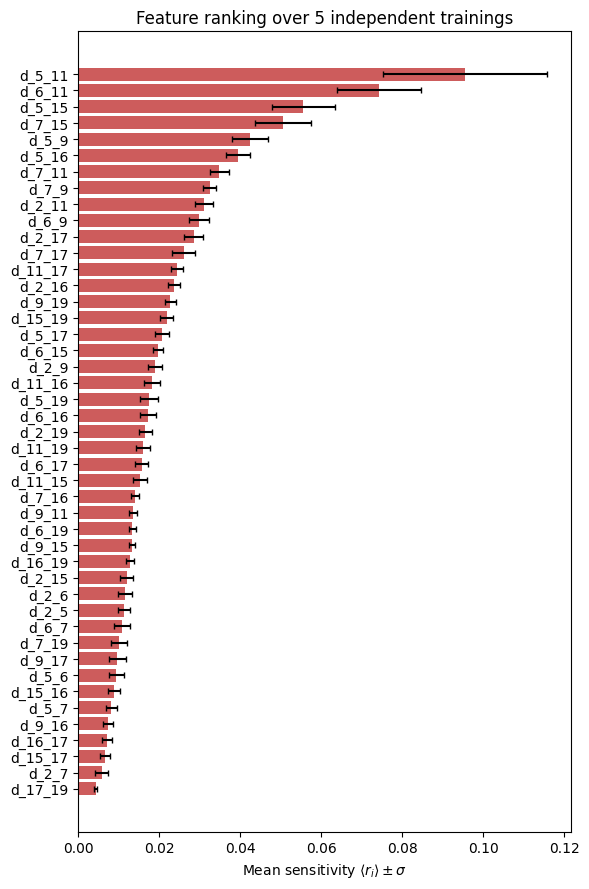

,feature,mean_sensitivity,std_sensitivity
0,d_5_11,0.095511,0.020256
1,d_6_11,0.074348,0.010363
2,d_5_15,0.055619,0.007695
3,d_7_15,0.050585,0.007014
4,d_5_9,0.042479,0.004497
5,d_5_16,0.039362,0.002950
6,d_7_11,0.034883,0.002292
7,d_7_9,0.032436,0.001554
8,d_2_11,0.031156,0.002237
9,d_6_9,0.029787,0.002445


In [26]:
# Consensus ranking: mean +/- std of the sensitivity over the N_RUNS trainings
all_names = runs[0]['sensitivity']['feature_names']
sens_matrix = np.array([r['sensitivity']['sensitivity']['Dataset'] for r in runs])  # (N_RUNS, n_features)

mean_sens = sens_matrix.mean(axis=0)
std_sens = sens_matrix.std(axis=0)

order = np.argsort(mean_sens)
names_sorted = np.array(all_names)[order]
mean_sorted, std_sorted = mean_sens[order], std_sens[order]

fig, ax = plt.subplots(figsize=(6, 9), dpi=100)
ax.barh(names_sorted, mean_sorted, xerr=std_sorted, color='indianred', ecolor='black', capsize=2)
ax.set_xlabel(r'Mean sensitivity $\langle r_i \rangle \pm \sigma$')
ax.set_title(f'Feature ranking over {N_RUNS} independent trainings')
plt.tight_layout()
plt.show()

ranking_df = pd.DataFrame({
    'feature': names_sorted[::-1],
    'mean_sensitivity': mean_sorted[::-1],
    'std_sensitivity': std_sorted[::-1],
}).reset_index(drop=True)
ranking_df


## 5.3 Test 2 — Number of network outputs

Extends the exploration already started in cell 40 of `04_full.ipynb` (the visual Ramachandran/histogram comparison) by additionally tracking the feature-sensitivity ranking as a function of the width of the last hidden layer, i.e. the dimensionality of the space onto which the LDA projection is subsequently applied.


In [28]:
# Define a few plotting functions

def plot_ramachandran(x,y,z,scatter=None, ax=None):
    # Setup plot
    if ax is None:
        _, ax = plt.subplots(figsize=(5,4.), dpi=100)
        ax.set_title(f'Ramachandran plot')

    # Plot countour plot
    h = ax.hexbin(x,y,C=z,cmap='fessa')
    cbar = plt.colorbar(h,ax=ax)
    cbar.set_label(f'Deep-LDA CV')

    ax.set_xlabel(r'$\phi$ [rad]')
    ax.set_ylabel(r'$\psi$ [rad]')

def plot_cv_histogram(s,label=None,ax=None,**kwargs):
    # Setup plot
    if ax is None:
        _, ax = plt.subplots(figsize=(5,4.), dpi=100)
        ax.set_title('Histogram')

    if (type(s)==torch.Tensor):
        s = s.squeeze(1).detach().numpy()

    # Plot histogram
    ax.hist(s,**kwargs)
    if label is not None:
        ax.set_xlabel(label)

In [30]:
X_dist = colvar.filter(like='d_', axis=1)

X = torch.tensor(X_dist.values, dtype=torch.float32)
y = torch.tensor(colvar['labels'].values, dtype=torch.long)

Seed set to 2000


--- n_outputs = 10 ---


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
Seed set to 2000
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


KEY:  data


KEY:  labels


--- n_outputs = 5 ---


Seed set to 2000
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


KEY:  data


KEY:  labels


--- n_outputs = 3 ---


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Seed set to 2000
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


KEY:  data


KEY:  labels


--- n_outputs = 1 ---
KEY:  data


KEY:  labels




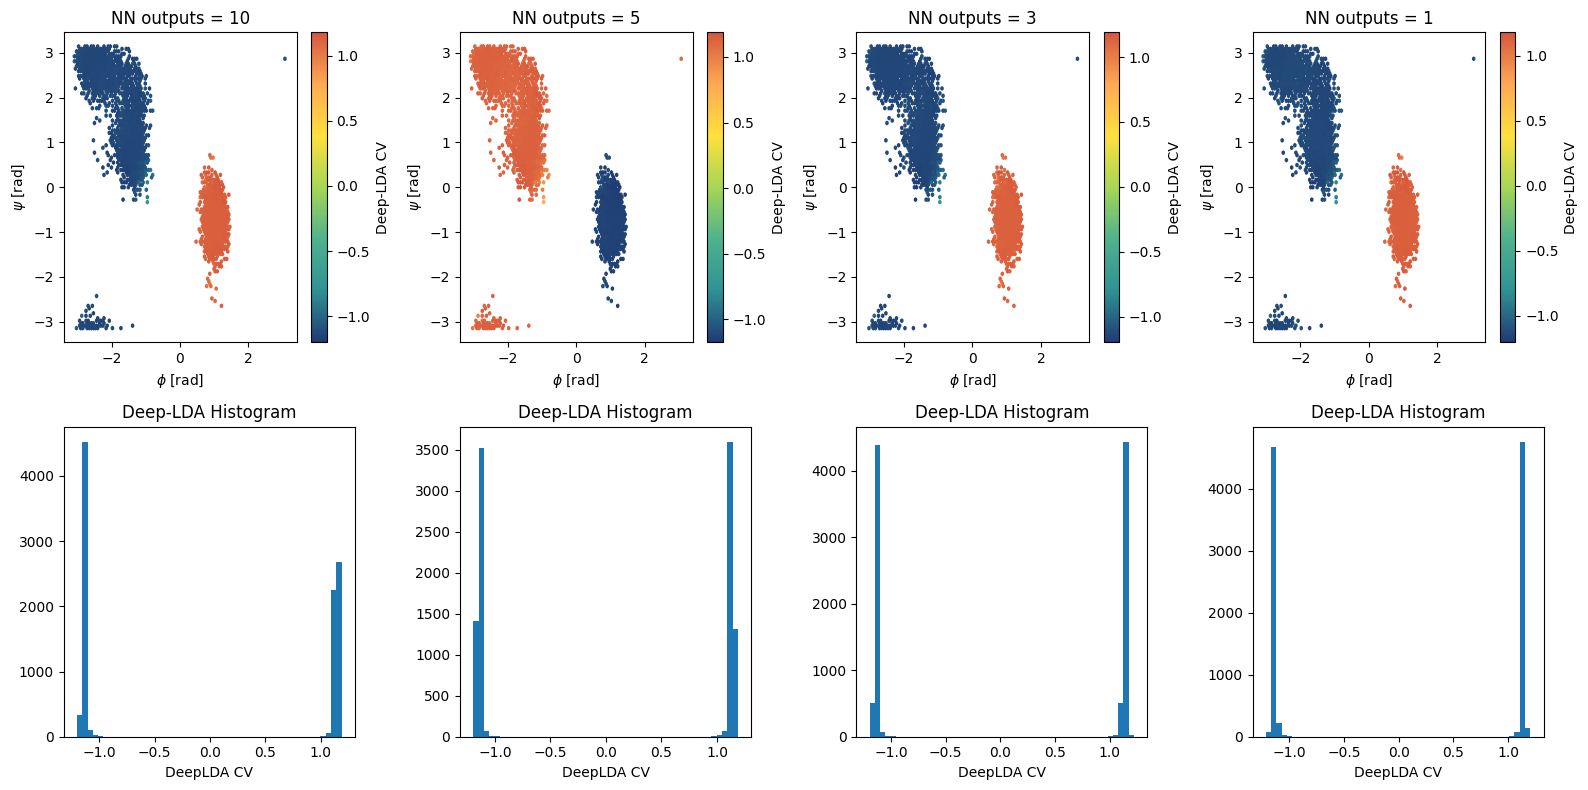

In [33]:
nn_out_list = [10, 5, 3, 1]
out_results = []

for out in nn_out_list:
    print(f'--- n_outputs = {out} ---')
    nodes_i = [dataset['data'].shape[-1], 30, 30, out]
    #model_i, metrics_i = train_deeplda(nodes_i, BASE_ACTIVATION, seed=2000 + out)
    model_i, metrics_i = train_deeplda(nodes_i, BASE_ACTIVATION, seed=2000)

    with torch.no_grad():
        s_i = model_i(X)

    res_i = sensitivity_analysis(model_i, dataset, feature_names=dataset.feature_names,
                                  per_class=False, plot_mode=None)
    out_results.append({'n_out': out, 'model': model_i, 's': s_i, 'sensitivity': res_i})

# Ramachandran + CV-histogram comparison (as in cell 40)
fig, axs = plt.subplots(2, len(nn_out_list), figsize=(16, 8), dpi=100)
for i, r in enumerate(out_results):
    axs[0][i].set_title(f'NN outputs = {r["n_out"]}')
    plot_ramachandran(colvar['phi'], colvar['psi'], r['s'], ax=axs[0][i])
    axs[1][i].set_title('Deep-LDA Histogram')
    plot_cv_histogram(r['s'], label='DeepLDA CV', bins=50, ax=axs[1][i])
plt.tight_layout()
plt.show()


Grafico dei Ranking salvato in: output/sensitivity_ranking_comparison.png


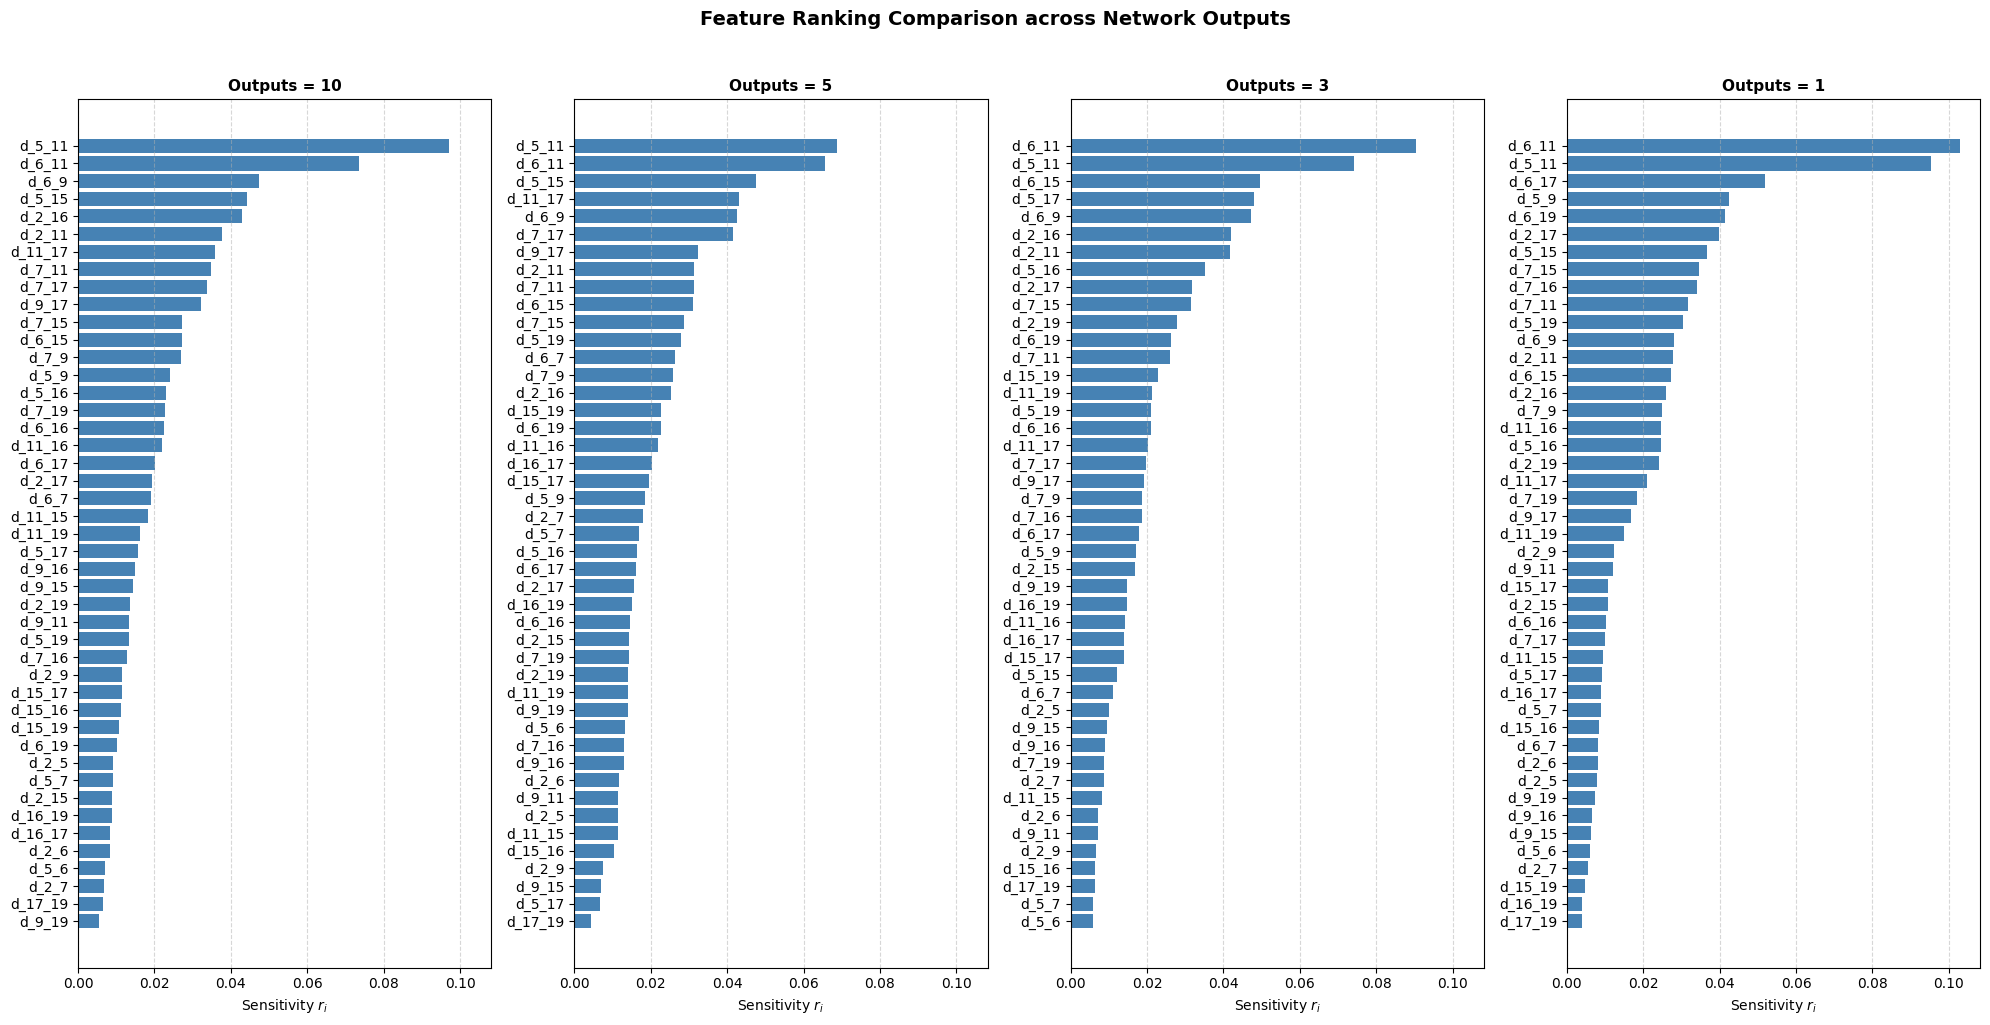

Grafico delle Distribuzioni salvato in: output/sensitivity_distributions_comparison.png


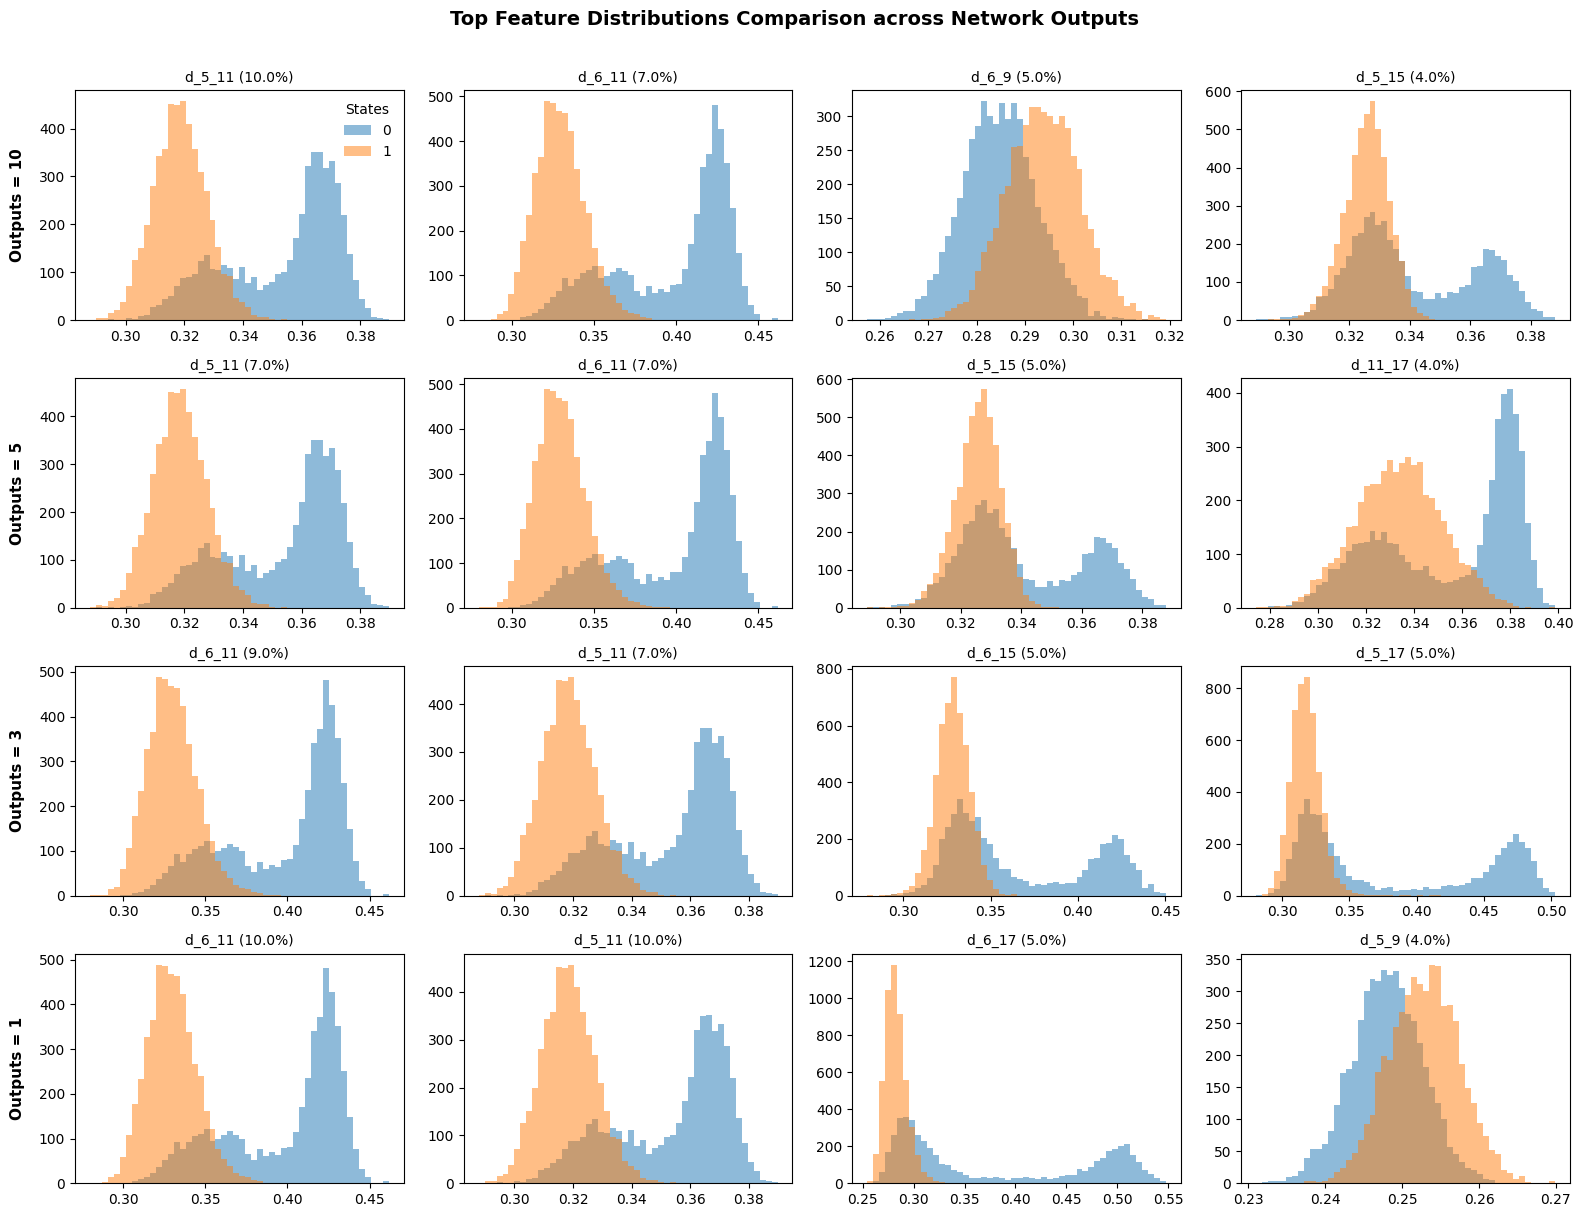

In [36]:
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURAZIONE PERCORSI ---
BASE_DIR = Path(".")
OUT_DIR = BASE_DIR / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plot_n_features = 4
n_configs = len(out_results)

# ==========================================
# FIGURA 1: CONFRONTO DEI RANKING (BARH)
# ==========================================
fig1, axs1 = plt.subplots(1, n_configs, figsize=(20, 10), dpi=100, sharex=True)
fig1.suptitle(
    "Feature Ranking Comparison across Network Outputs",
    fontsize=14,
    weight="bold",
    y=1.02,
)

for i, r in enumerate(out_results):
    names = np.array(r["sensitivity"]["feature_names"])
    sens = np.array(r["sensitivity"]["sensitivity"]["Dataset"])
    order = np.argsort(sens)

    # Plot del grafico a barre nella colonna corrispondente
    axs1[i].barh(names[order], sens[order], color="steelblue")
    axs1[i].set_title(f"Outputs = {r['n_out']}", weight="bold", fontsize=11)
    axs1[i].set_xlabel(r"Sensitivity $r_i$")
    axs1[i].grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

# Salvataggio Figura 1
filepath_ranking = OUT_DIR / "sensitivity_ranking_comparison.png"
fig1.savefig(filepath_ranking, bbox_inches="tight", dpi=100)
print(f"Grafico dei Ranking salvato in: {filepath_ranking}")
plt.show()
plt.close(fig1)


# ==========================================
# FIGURA 2: CONFRONTO DELLE DISTRIBUZIONI (ISTOGRAMMI)
# ==========================================
# Griglia: ogni riga è una configurazione, ogni colonna è una delle top feature
fig2, axs2 = plt.subplots(
    n_configs, plot_n_features, figsize=(16, 12), dpi=100
)
fig2.suptitle(
    "Top Feature Distributions Comparison across Network Outputs",
    fontsize=14,
    weight="bold",
    y=1.01,
)

for i, r in enumerate(out_results):
    names = np.array(r["sensitivity"]["feature_names"])
    sens = np.array(r["sensitivity"]["sensitivity"]["Dataset"])
    order = np.argsort(sens)

    # Prendiamo le top 4 in ordine decrescente (dalla più importante)
    top_names = names[order][-plot_n_features:][::-1]
    top_sens = sens[order][-plot_n_features:][::-1]

    for j, (name, s) in enumerate(zip(top_names, top_sens)):
        ax = axs2[i][j]

        # Plot istogramma su colvar
        colvar.pivot(columns="labels")[name].plot.hist(
            bins=50, alpha=0.5, ax=ax
        )
        ax.set_title(f"{name} ({np.round(s * 100)}%)", fontsize=10)
        ax.set_ylabel("")  # Rimuove il testo dall'asse Y per non intasare

        # Etichetta di riga (la mettiamo solo sulla prima colonna di ogni riga)
        if j == 0:
            ax.set_ylabel(
                f"Outputs = {r['n_out']}",
                weight="bold",
                fontsize=11,
                labelpad=10,
            )

        # Mostra la legenda solo nel primissimo grafico in alto a sinistra
        if i == 0 and j == 0:
            ax.legend(title="States", frameon=False, loc="upper right")
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

plt.tight_layout()

# Salvataggio Figura 2
filepath_dist = OUT_DIR / "sensitivity_distributions_comparison.png"
fig2.savefig(filepath_dist, bbox_inches="tight", dpi=100)
print(f"Grafico delle Distribuzioni salvato in: {filepath_dist}")
plt.show()
plt.close(fig2)

## 5.4 Test 3 — Activation function

Same architecture as the baseline model (`BASE_NODES`), varying only the nonlinearity applied in the hidden layers.


In [44]:
activations = ['relu','tanh','shifted_softplus','leaky_relu']
act_results = []

for act in activations:
    print(f'--- activation = {act} ---')
    model_i, metrics_i = train_deeplda(BASE_NODES, act, seed=3000)

    with torch.no_grad():
        s_i = model_i(X)

    res_i = sensitivity_analysis(model_i, dataset, feature_names=dataset.feature_names,
                                  per_class=False, plot_mode=None)
    act_results.append({'activation': act, 'model': model_i, 'metrics': metrics_i,
                         's': s_i, 'sensitivity': res_i})


Seed set to 3000
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


--- activation = relu ---


Seed set to 3000
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


KEY:  data


KEY:  labels


--- activation = tanh ---


Seed set to 3000
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


KEY:  data


KEY:  labels


--- activation = shifted_softplus ---


Seed set to 3000
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


KEY:  data


KEY:  labels


--- activation = leaky_relu ---
KEY:  data


KEY:  labels




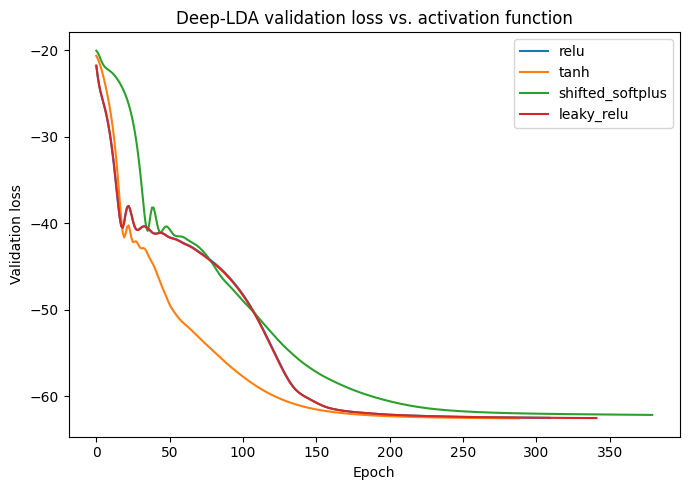

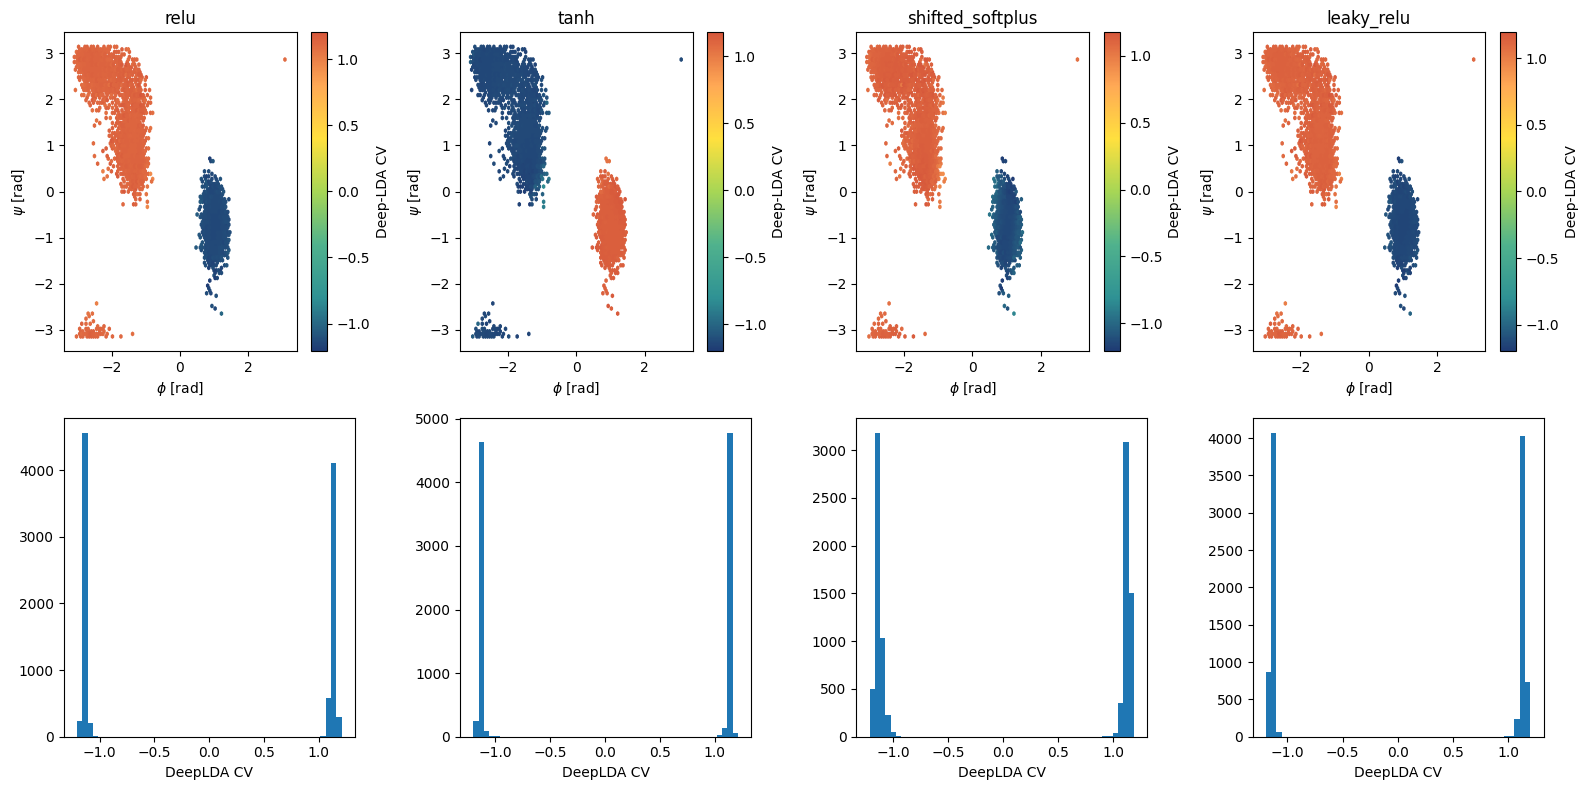

In [45]:
# Validation-loss curves
fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
for r in act_results:
    vloss = r['metrics'].metrics['valid_loss']
    ax.plot(np.arange(len(vloss)), vloss, label=r['activation'])
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation loss')
ax.set_title('Deep-LDA validation loss vs. activation function')
ax.legend()
plt.tight_layout()
plt.show()

# Ramachandran + CV-histogram grid
fig, axs = plt.subplots(2, len(activations), figsize=(4 * len(activations), 8), dpi=100)
for i, r in enumerate(act_results):
    axs[0][i].set_title(r['activation'])
    plot_ramachandran(colvar['phi'], colvar['psi'], r['s'], ax=axs[0][i])
    plot_cv_histogram(r['s'], label='DeepLDA CV', bins=50, ax=axs[1][i])
plt.tight_layout()
plt.show()


Grafico dei Ranking salvato in: output/activation_sensitivity_ranking.png


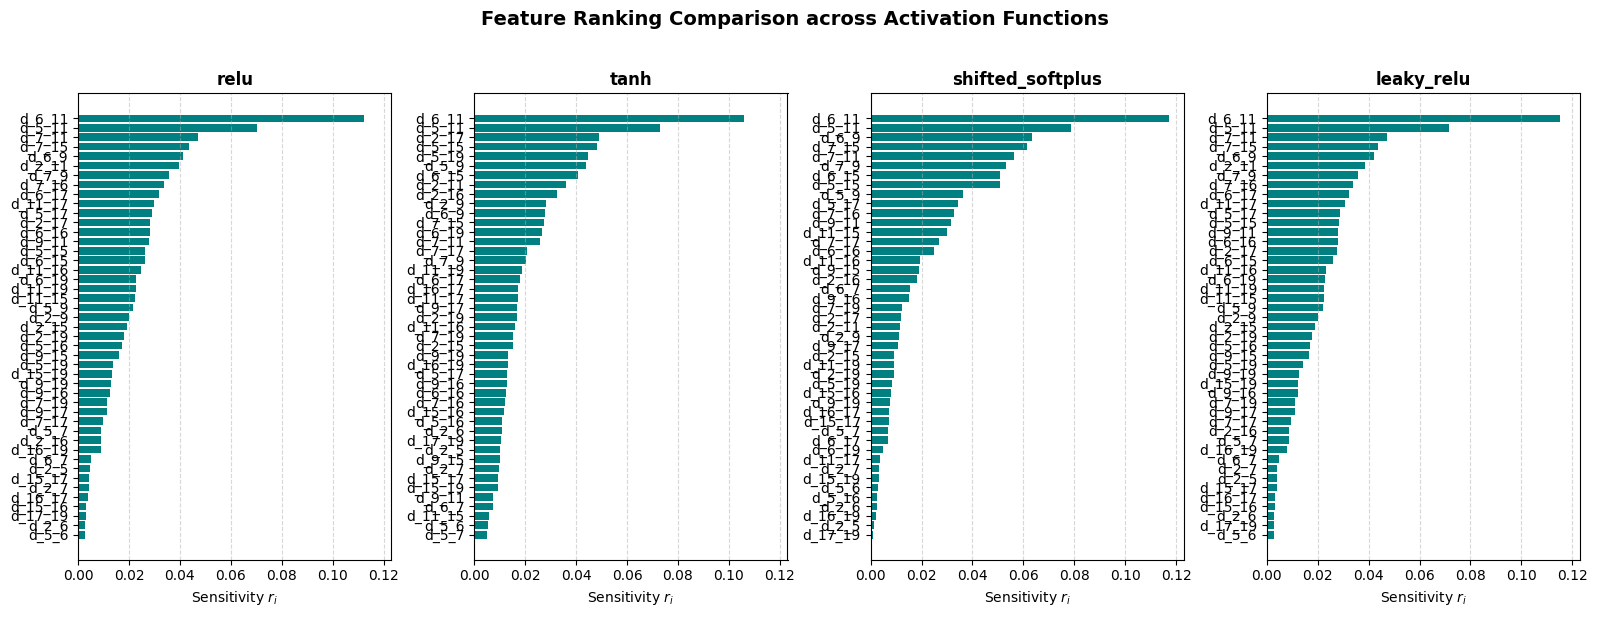

Grafico delle Distribuzioni salvato in: output/activation_sensitivity_distributions.png


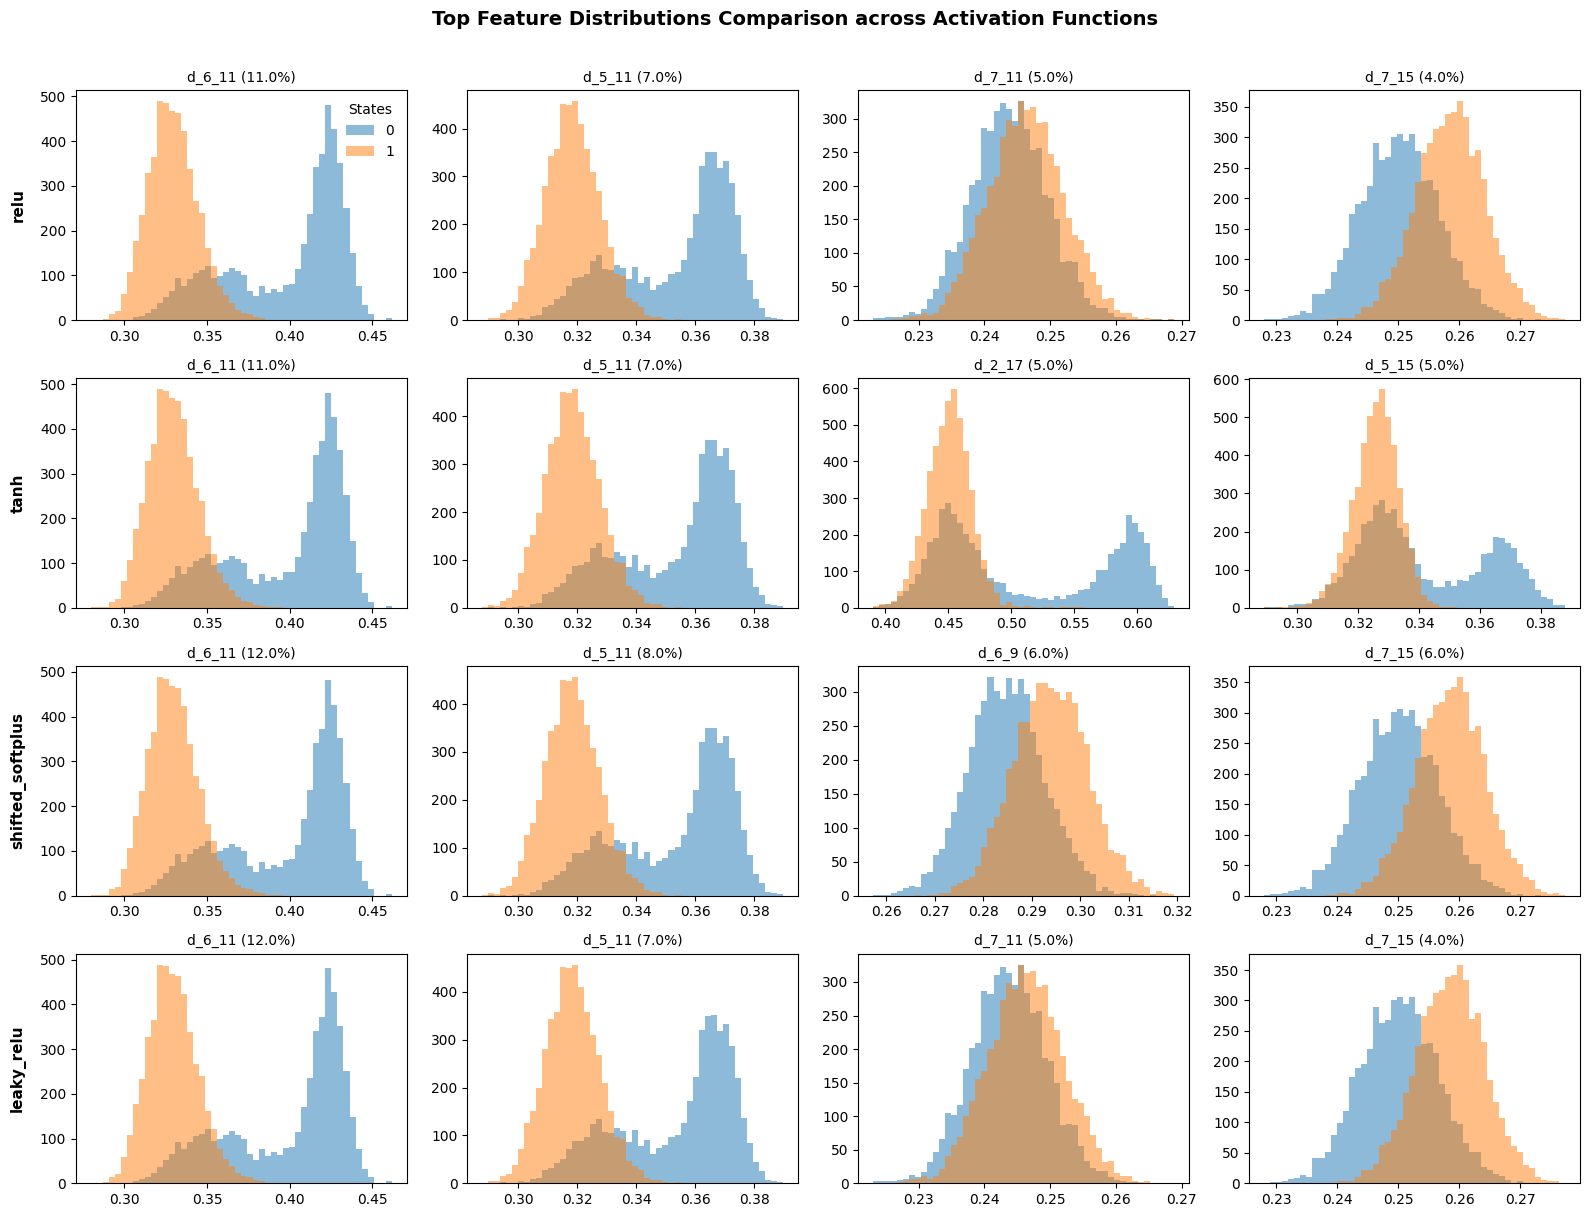

In [47]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURAZIONE PERCORSI ---
BASE_DIR = Path(".")
OUT_DIR = BASE_DIR / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plot_n_features = 4
n_acts = len(act_results)

# ==========================================
# FIGURA 1: CONFRONTO DEI RANKING (BARH)
# ==========================================
fig1, axs1 = plt.subplots(1, n_acts, figsize=(4 * n_acts, 6), dpi=100, sharex=True)

# Gestione del caso limite se c'è una sola attivazione
if n_acts == 1:
    axs1 = [axs1]

fig1.suptitle(
    "Feature Ranking Comparison across Activation Functions",
    fontsize=14,
    weight="bold",
    y=1.02,
)

for i, r in enumerate(act_results):
    names = np.array(r["sensitivity"]["feature_names"])
    sens = np.array(r["sensitivity"]["sensitivity"]["Dataset"])
    order = np.argsort(sens)

    # Plot del grafico a barre per la specifica attivazione
    axs1[i].barh(names[order], sens[order], color="teal")
    axs1[i].set_title(r["activation"], weight="bold", fontsize=12)
    axs1[i].set_xlabel(r"Sensitivity $r_i$")
    axs1[i].grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

# Salvataggio e mostra del Ranking
filepath_ranking = OUT_DIR / "activation_sensitivity_ranking.png"
fig1.savefig(filepath_ranking, bbox_inches="tight", dpi=100)
print(f"Grafico dei Ranking salvato in: {filepath_ranking}")
plt.show()
plt.close(fig1)


# ==========================================
# FIGURA 2: CONFRONTO DELLE DISTRIBUZIONI (ISTOGRAMMI)
# ==========================================
# Matrice: ogni riga è una funzione di attivazione, ogni colonna una top feature
fig2, axs2 = plt.subplots(n_acts, plot_n_features, figsize=(16, 3 * n_acts), dpi=100)

# Gestione dell'indicizzazione se c'è una sola riga (un'unica attivazione)
if n_acts == 1:
    axs2 = np.expand_dims(axs2, axis=0)

fig2.suptitle(
    "Top Feature Distributions Comparison across Activation Functions",
    fontsize=14,
    weight="bold",
    y=1.01,
)

for i, r in enumerate(act_results):
    names = np.array(r["sensitivity"]["feature_names"])
    sens = np.array(r["sensitivity"]["sensitivity"]["Dataset"])
    order = np.argsort(sens)

    # Estraiamo le top 4 feature (dalla più rilevante alla meno rilevante)
    top_names = names[order][-plot_n_features:][::-1]
    top_sens = sens[order][-plot_n_features:][::-1]

    for j, (name, s) in enumerate(zip(top_names, top_sens)):
        ax = axs2[i][j]

        # Plot istogramma basato sulle label del tuo colvar
        colvar.pivot(columns="labels")[name].plot.hist(
            bins=50, alpha=0.5, ax=ax
        )
        ax.set_title(f"{name} ({np.round(s * 100)}%)", fontsize=10)
        ax.set_ylabel("")  # Rimuove la scritta 'Frequency' ripetitiva

        # Etichetta laterale della riga (solo sulla prima colonna)
        if j == 0:
            ax.set_ylabel(
                r["activation"],
                weight="bold",
                fontsize=11,
                labelpad=10,
            )

        # Mostra la legenda degli stati solo nel primo sotto-grafico assoluto
        if i == 0 and j == 0:
            ax.legend(title="States", frameon=False, loc="upper right")
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

plt.tight_layout()

# Salvataggio e mostra delle Distribuzioni
filepath_dist = OUT_DIR / "activation_sensitivity_distributions.png"
fig2.savefig(filepath_dist, bbox_inches="tight", dpi=100)
print(f"Grafico delle Distribuzioni salvato in: {filepath_dist}")
plt.show()
plt.close(fig2)

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as ClassicLDA
import numpy as np

X_train = dataset.tensors[0].detach().cpu().numpy()
y_train = dataset.tensors[1].detach().cpu().numpy().flatten()


# 1. Classic LDA (Senza Deep Learning)
# Ottimo benchmark per vedere se la non-linearità delle NN è davvero necessaria
lda_classic = ClassicLDA()
X_lda = lda_classic.fit_transform(X_train, y_train)

# 2. Random Forest Classifier
# Utile per ottenere l'importanza delle feature (feature importance) nativa
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Ottieni l'importanza dei descrittori geometrici (distanze d_)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = colvar.filter(regex='^d_').columns.tolist()

print("Top 5 Descrittori per importanza (Random Forest):")
for f in range(5):
    idx = indices[f]
    print(f"{f + 1}. Feature {feature_names[idx]} ({importances[idx]:.4f})")

Top 5 Descrittori per importanza (Random Forest):
1. Feature d_5_11 (0.2113)
2. Feature d_6_11 (0.1593)
3. Feature d_6_19 (0.0876)
4. Feature d_11_16 (0.0729)
5. Feature d_11_17 (0.0587)


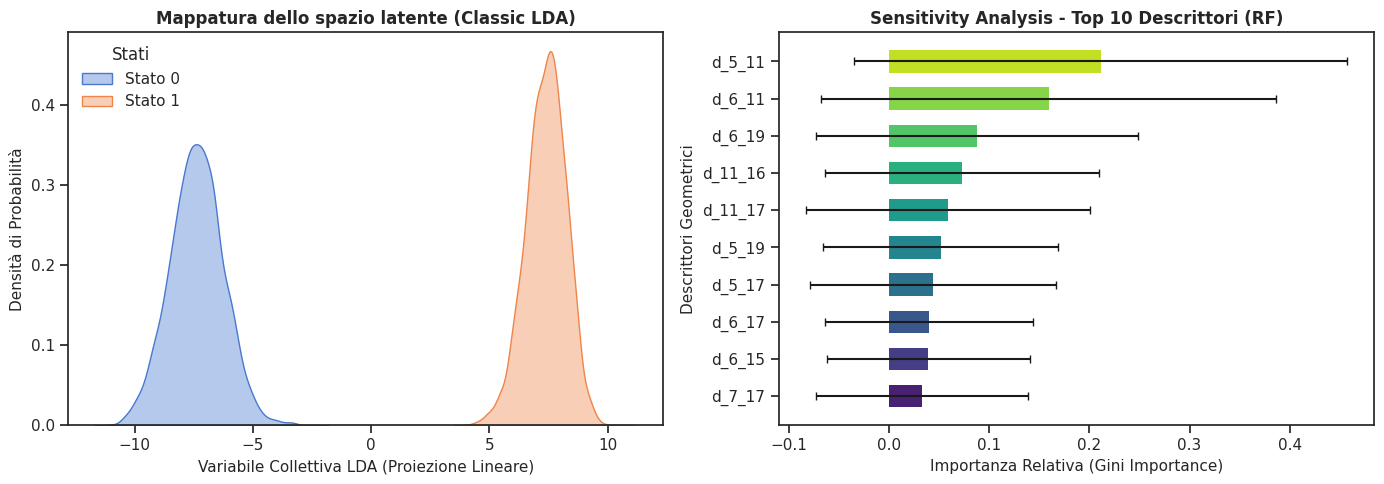

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurazione stile grafici
sns.set_theme(style="ticks", palette="muted")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# =========================================================================
# GRAFICO 1: Mappatura della CV tramite Classic LDA (Distribuzione degli Stati)
# =========================================================================
for state in np.unique(y_train):
    mask = (y_train == state)
    sns.kdeplot(
        X_lda[mask].flatten(), 
        ax=ax[0], 
        fill=True, 
        alpha=0.4, 
        label=f"Stato {state}"
    )

ax[0].set_title("Mappatura dello spazio latente (Classic LDA)", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Variabile Collettiva LDA (Proiezione Lineare)", fontsize=11)
ax[0].set_ylabel("Densità di Probabilità", fontsize=11)
ax[0].legend(title="Stati", frameon=False)

# =========================================================================
# GRAFICO 2: Sensitivity Analysis tramite Random Forest (Feature Importance)
# =========================================================================
top_n = 10
top_indices = indices[:top_n]
top_importances = importances[top_indices]
top_names = [feature_names[i] for i in top_indices]

# Calcolo deviazione standard delle importanze tra i vari alberi
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
top_std = std[top_indices]

# Usiamo direttamente ax.barh di Matplotlib per evitare i bug di compatibilità di xerr in Seaborn
# Questo garantisce la formattazione perfetta delle barre di errore (xerr)
colors = sns.color_palette("viridis", n_colors=top_n)[::-1] # Invertito per far coincidere il colore più intenso alla feature più importante
ax[1].barh(
    top_names, 
    top_importances, 
    xerr=top_std, 
    color=colors, 
    edgecolor='none',
    height=0.6,
    capsize=3 # Aggiunge i terminali alle barre di errore per renderle più leggibili
)

ax[1].invert_yaxis() # Inverte l'asse per avere la feature più importante in alto
ax[1].set_title(f"Sensitivity Analysis - Top {top_n} Descrittori (RF)", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Importanza Relativa (Gini Importance)", fontsize=11)
ax[1].set_ylabel("Descrittori Geometrici", fontsize=11)

# Ottimizzazione layout e mostra
plt.tight_layout()
plt.show()

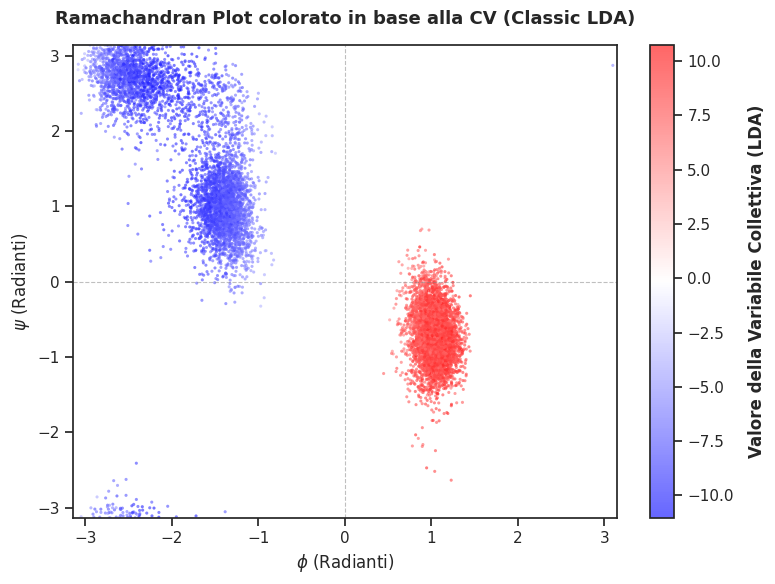

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Recuperiamo gli angoli phi e psi dal DataFrame originale
# Nota: Assicurati che 'colvar' contenga i dati nello stesso ordine del dataset
phi = colvar['phi'].values
psi = colvar['psi'].values

# Se gli angoli sono in radianti e preferisci i gradi (-180, 180), scommenta le righe sotto:
# if np.max(np.abs(phi)) <= np.pi:
#     phi = np.degrees(phi)
#     psi = np.degrees(psi)

# 2. Assocviamo il valore della CV calcolata (usiamo la proiezione del Classic LDA)
# X_lda ha forma (n_samples, 1), lo riduciamo a 1D con flatten()
cv_values = X_lda.flatten()

# =========================================================================
# CONFIGURAZIONE E GRAFICO
# =========================================================================
plt.figure(figsize=(8, 6))
sns.set_theme(style="ticks")

# Creiamo lo scatter plot usando phi e psi come assi e cv_values come colore (cmap)
sc = plt.scatter(
    phi, 
    psi, 
    c=cv_values, 
    cmap="bwr",       # Blue-White-Red: ottimo per mostrare la transizione/polarità della CV
    s=5,              # Dimensione dei punti (piccola per evitare sovrapposizioni eccessive)
    alpha=0.6,        # Trasparenza per vedere la densità
    edgecolors='none'
)

# Aggiunta della barra del colore per interpretare la CV
cbar = plt.colorbar(sc)
cbar.set_label('Valore della Variabile Collettiva (LDA)', fontsize=12, fontweight='bold', labelpad=10)

# Limiti tipici del grafico di Ramachandran (sia in gradi che in radianti)
if np.max(np.abs(phi)) > np.pi:
    plt.xlim(-180, 180)
    plt.ylim(-180, 180)
    plt.xlabel(r'$\phi$ (Gradi)', fontsize=12)
    plt.ylabel(r'$\psi$ (Gradi)', fontsize=12)
else:
    plt.xlim(-np.pi, np.pi)
    plt.ylim(-np.pi, np.pi)
    plt.xlabel(r'$\phi$ (Radianti)', fontsize=12)
    plt.ylabel(r'$\psi$ (Radianti)', fontsize=12)

# Linee di riferimento centrali (opzionali ma utili per orientarsi)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

plt.title('Ramachandran Plot colorato in base alla CV (Classic LDA)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()